# Superstore Sales & Profitability Analytics

## 1.1 Project Overview

This project analyzes retail sales transaction data to understand the key factors driving sales performance and profitability.

The analysis focuses on identifying profitable and underperforming product categories, sub-categories, customer segments, and regions, while also examining the relationship between discounting and profitability. The objective is to translate transactional sales data into actionable business insights that can support better pricing, product, and sales decisions.

The dataset used in this project was obtained from Kaggle and contains historical retail transaction records, including information on orders, customers, products, sales, quantity, discounts, profit, returns, regions, and customer segments.

Rather than focusing only on total sales, this analysis considers profitability alongside revenue in order to identify areas where high sales may not necessarily translate into strong financial performance.

## 1.2 Business Problem

A business may generate substantial sales while still experiencing weak profitability due to excessive discounting, low-margin products, or differences in performance across products, customers, and regions.

Therefore, management needs to understand:

- Which product categories and sub-categories generate the most revenue?
- Which products and sub-categories generate the most profit?
- Which areas generate high sales but weak or negative profitability?
- How is discounting associated with profit margins?
- Which regions and customer segments perform best?
- Which products contribute disproportionately to losses?
- How do sales and profitability change over time?
- What areas should management prioritize for improvement?





In [7]:
# @title
# Data Dimensions
print(df.shape)

(9994, 23)


The data had 9994 transactions

In [15]:
# @title
print(df["Shipping Days"].value_counts().sort_index().head(30))

Shipping Days
0     2227
1      205
2      731
3      531
4     1380
5     1080
6      554
7      273
28      12
29       3
30      74
31      75
32      12
33      25
34      75
35      33
36      44
37      13
59      82
60      32
61     276
62      71
63      20
64      25
65      23
66      19
67       7
89      44
90      26
91      75
Name: count, dtype: int64


From this result we can see that 2227 orders were delivered on the same day. However this result also shows data quality issues, becuase of the jump between day 7 and day 28.

In [16]:
# @title
df[df["Shipping Days"] == 0]["Ship Mode"].value_counts()

,count
Ship Mode,
Standard Class,1238
Same Day,521
Second Class,307
First Class,161


This confirms our data quality issue. When we look at the shipping days with 0 shipping days column against the shipping mode column we find that same day deliveries were only 521. This requires further investigation.

In [17]:
# @title
df[df["Shipping Days"] >= 28][
    [
        "Order ID",
        "Order Date",
        "Ship Date",
        "Shipping Days",
        "Ship Mode"
    ]
].sort_values("Shipping Days").head(30)

,Order ID,Order Date,Ship Date,Shipping Days,Ship Mode
2348,CA-2017-109701,2017-02-12,2017-03-12,28,Same Day
2350,CA-2017-109701,2017-02-12,2017-03-12,28,Same Day
2352,CA-2017-109701,2017-02-12,2017-03-12,28,Same Day
2351,CA-2017-109701,2017-02-12,2017-03-12,28,Same Day
4768,CA-2017-158883,2017-02-06,2017-03-06,28,Same Day
2349,CA-2017-109701,2017-02-12,2017-03-12,28,Same Day
4930,US-2014-138828,2014-02-09,2014-03-09,28,First Class
4929,US-2014-138828,2014-02-09,2014-03-09,28,First Class
6954,CA-2015-129917,2015-02-10,2015-03-10,28,First Class
6953,CA-2015-129917,2015-02-10,2015-03-10,28,First Class


Upon conducting further investigation we find that some of the orders tagged same day delivery yet they were delivered after 28 days. With this we can conclude that the shipping date column is not reliable. However we cannot eliminate the column.

During exploratory data profiling, inconsistencies were identified in shipping dates. Calculated shipping durations exhibited clusters around 30, 60, 90 and 180+ days, with some "Same Day" shipments showing durations exceeding 28 days. Further inspection revealed systematic month shifts while preserving the day of the month. Because the correct shipping dates could not be reliably reconstructed, shipping duration was excluded from downstream operational analysis.

Product Identifier Inconsistency: 32 Product IDs are associated with multiple product names, while several product names are associated with multiple Product IDs. These inconsistencies occur frequently enough to affect SKU-level analysis. However, Category and Sub-Category remain consistent across the identified records. Because the underlying transactions contain valid sales and profitability information, records will be retained. Product Name will be used for product-level reporting, while Product ID will be retained as a source identifier rather than treated as a unique product key.

#### Return Analysis

In [26]:
# @title
print(df["Returned"].value_counts(dropna=False))

Returned
Not    9194
Yes     800
Name: count, dtype: int64


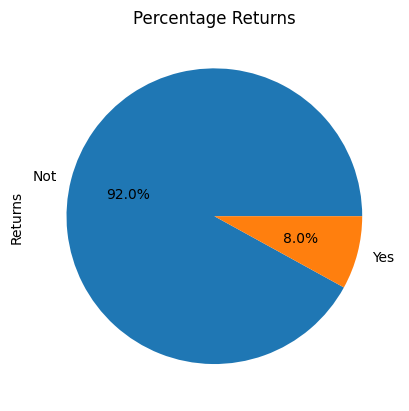

In [67]:
# @title
returns = df["Returned"].value_counts(dropna=False)
returns.plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage Returns")
plt.ylabel("Returns")
plt.show()

Only 8% of the sales were returned, which is a small percentage but needs to be investigated. It is important to note that  we cannot use this to make a conclusion that the return rate is 8% because we may have duplicates in order name etc.

In [28]:
# @title
returned_orders = df[
    df["Returned"] == "Yes"
]["Order ID"].nunique()

total_orders = df["Order ID"].nunique()

order_return_rate = (
    returned_orders / total_orders
) * 100

print(f"Returned orders: {returned_orders}")
print(f"Total orders: {total_orders}")
print(f"Order-level return rate: {order_return_rate:.2f}%")

Returned orders: 296
Total orders: 5009
Order-level return rate: 5.91%


Approximately 5.9% of orders contained a returned item. This is a metric we can use because we have unique order IDs

In [30]:
# @title
return_by_category = (
    df.groupby("Category")["Returned"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(return_by_category)

Category
Technology         8.446129
Furniture          8.062235
Office Supplies    7.849320
Name: Returned, dtype: float64


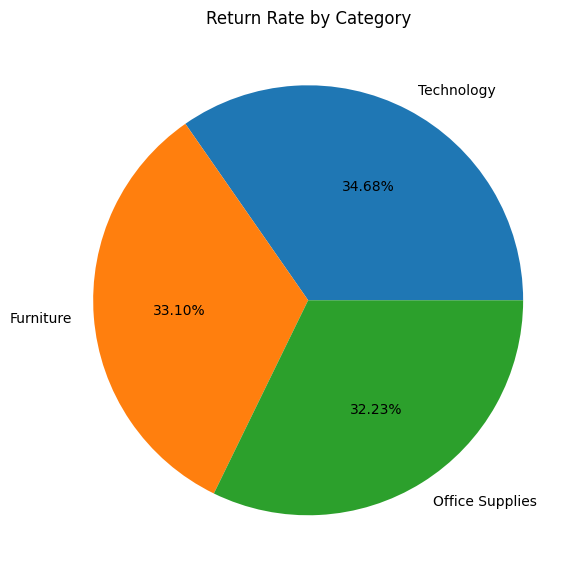

In [75]:
# @title
plt.figure(figsize=(6, 6))

plt.pie(
    return_by_category,
    labels=return_by_category.index,
    autopct="%.2f%%"
)
plt.title("Return Rate by Category")
plt.tight_layout()
plt.show()

Technology has the highest observed return rate at 34.68%, although return rates are relatively similar across the three categories.

The Returned field contains 9,194 non-returned and 800 returned transaction records, with no apparent missing or invalid values. The row-level return rate is 8.0%, while 296 of 5,009 unique orders contain a return, giving an order-level return rate of 5.91%. No orders contain a mixture of returned and non-returned items, indicating that return status is consistent within orders. No cleaning is required for the return field.

#### Profit and loss making transactions

In [31]:
# @title
print("Negative Sales:", (df["Sales"] < 0).sum())
print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Negative Discount:", (df["Discount"] < 0).sum())
print("Negative Profit:", (df["Profit"] < 0).sum())

Negative Sales: 0
Negative Quantity: 0
Negative Discount: 0
Negative Profit: 1871


The data has 1871 negative profits, meaning we could be making losses generally and this is worth investigating.

In [32]:
# @title
print(df[["Sales", "Quantity", "Discount", "Profit"]].describe())

              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000


The maximum profit is 8399 and minimum is -6599 while the man is 28 and the standard deviation 234. The profit distribution is highly dispersed and likely heavily influenced by extreme observations.


The discount minimum is 0% and maximum is 80%. This raises the quetsion, Are higher discounts associated with lower profitability?

In [34]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_index()
)

print(discount_profit)

          count        mean    median        min        max
Discount                                                   
0.00       4798   66.900292   15.9952     0.0000  8399.9760
0.10         94   96.055074   54.3240    -8.0980   679.9960
0.15         52   27.288298   14.0980   -40.1960   225.7350
0.20       3657   24.702572    6.4944 -1049.3406  3919.9888
0.30        227  -45.679636  -25.3764  -630.8820   156.0470
0.32         27  -88.560656  -46.9764  -437.5404    -6.0196
0.40        206 -111.927429  -57.6242 -1862.3124  1119.9968
0.45         11 -226.646464 -167.3184  -458.1468   -76.6062
0.50         66 -310.703456 -185.2767 -3839.9904    -1.8295
0.60        138  -43.077212  -12.0617  -427.4500    -0.7566
0.70        418  -95.874060   -9.2023 -6599.9780    -0.5964
0.80        300 -101.796797  -14.0498 -3701.8928    -0.9452


Higher discount levels are strongly associated with lower profitability, with average profit becoming negative from the 30% discount level onward.

At 70% and 80% discounts the average profits are -95.8  and
-101 respectively implying that deep discounting may be destroying margins on some products.

In [36]:
# Overall sales by category

sales_by_category = (df.groupby("Category")["Sales"].agg(["sum", "mean","count"]).sort_values("sum", ascending=False))
print(sales_by_category)

                         sum        mean  count
Category                                       
Technology       836154.0330  452.709276   1847
Furniture        741999.7953  349.834887   2121
Office Supplies  719047.0320  119.324101   6026


Technology has the highest number of sales followed closely by Furniture and Office Supplies.

In [37]:
# @title
# Percentage share of sales by category
category_sales = df.groupby("Category")["Sales"].sum()
total_sales = category_sales.sum()
percentage_share = (category_sales / total_sales) * 100
print(percentage_share)

Category
Furniture          32.300171
Office Supplies    31.301008
Technology         36.398821
Name: Sales, dtype: float64


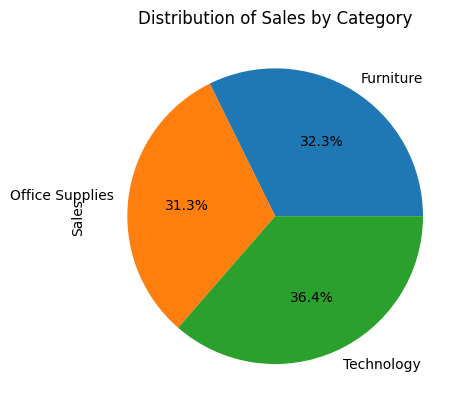

In [38]:
# @title
# Visualizing the distribution of sales
category_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Sales by Category")
plt.ylabel("Sales")
plt.show()

Technology is the largest revenue-generating category, contributing 36.4% of total sales despite accounting for only 18.5% of transactions. Its high average transaction value (452.71)  contrasts with Office Supplies, which generates 31.3% of sales from 60.3% of transactions at an average value of only $119.32. This indicates that Technology relies on fewer, higher-value transactions, while Office Supplies is driven primarily by transaction volume.

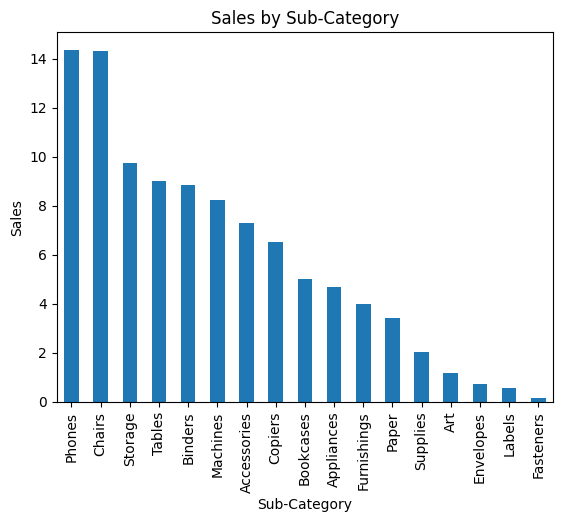

In [41]:
# @title
# Visualization
subcategory_share.plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.show()

Phones and Chairs have the highest sales compared to Fasterners and Labels when we narrow down our analysis to subcategory level.

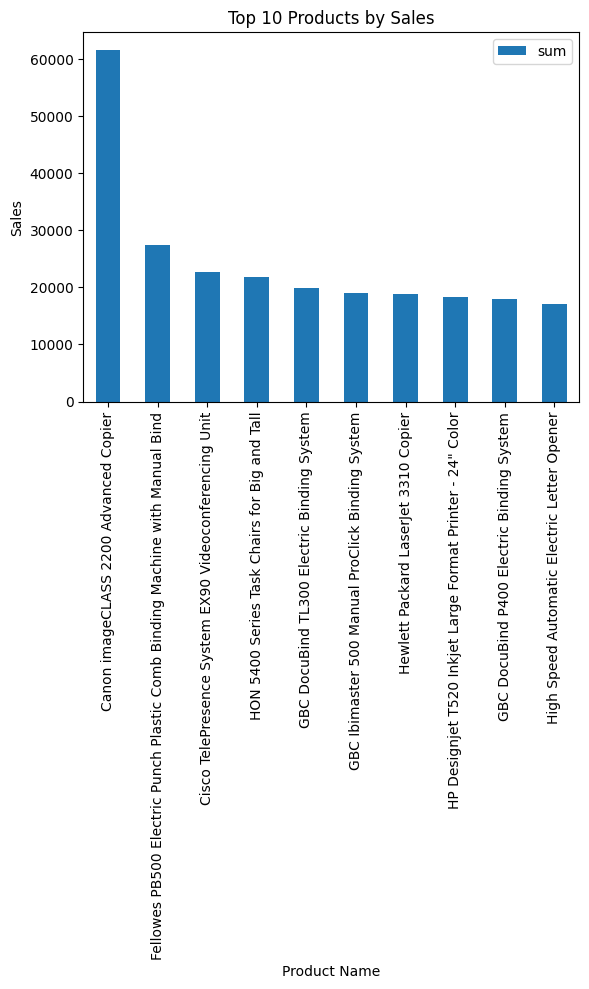

In [43]:
# Visualize the top 10 products
top_products_by_sales.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.show()

Canon imageCLASS 2200 Advanced Copier have the highest sales when we narrow down our analysis to product level.

#### 9. Regional Analysis

In [44]:
# @title
# Sales by region
sales_by_region = (df.groupby("Region")["Sales"].agg(["sum"]).sort_values("sum", ascending=False))
print(sales_by_region)

                 sum
Region              
West     725457.8245
East     678781.2400
Central  501239.8908
South    391721.9050


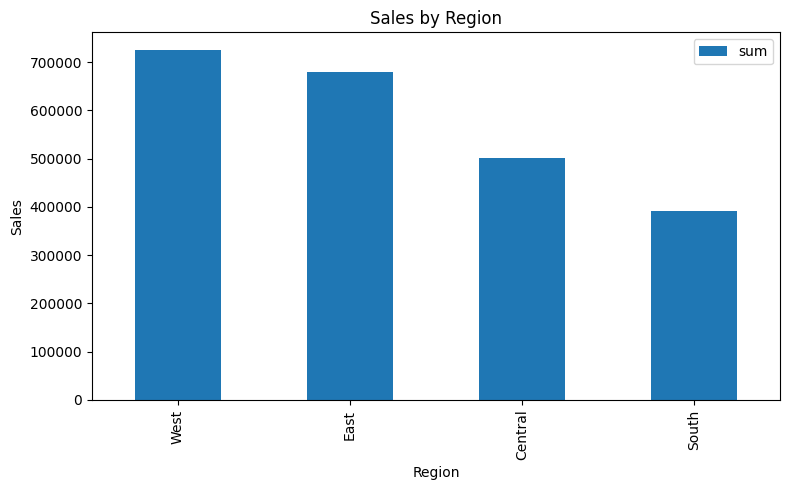

In [45]:
#Visualization
sales_by_region.plot(kind= 'bar',figsize=(8,5))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [47]:
# @title
# yearly sales
sales_by_year = (df.groupby(df["Order Date"].dt.year)["Sales"].agg(["sum"]))
print(sales_by_year)

                    sum
Order Date             
2014        484247.4981
2015        470532.5090
2016        609205.5980
2017        733215.2552


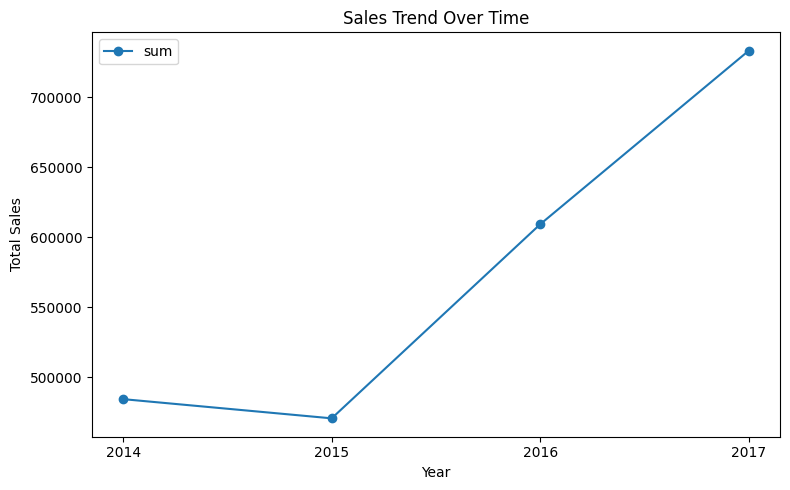

In [48]:
# @title
# Visualize
sales_by_year.plot(kind="line",marker = 'o',figsize=(8,5))
plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(sales_by_year.index)
plt.tight_layout()
plt.show()

Sales have had unpward trend from 2015 to date (2017).

#### The biggest question
What actually makes money, so that we capitalize that and increase our profit margins further.

In [50]:
# @title
# Profit margin
profit_margin= (df.groupby("Sub-Category").agg(Sales = ("Sales","sum"),
                                              Profit =("Profit","sum")
                                              )
)
profit_margin["Profit Margin"] = profit_margin["Profit"]/profit_margin["Sales"]*100

print(profit_margin.sort_values("Profit Margin",ascending=False))

                    Sales      Profit  Profit Margin
Sub-Category                                        
Labels         12486.3120   5546.2540      44.418672
Paper          78479.2060  34053.5693      43.391837
Envelopes      16476.4020   6964.1767      42.267582
Copiers       149528.0300  55617.8249      37.195585
Fasteners       3024.2800    949.5182      31.396504
Accessories   167380.3180  41936.6357      25.054700
Art            27118.7920   6527.7870      24.071083
Appliances    107532.1610  18138.0054      16.867517
Binders       203412.7330  30221.7633      14.857361
Furnishings    91705.1640  13059.1436      14.240358
Phones        330007.0540  44515.7306      13.489327
Storage       223843.6080  21278.8264       9.506113
Chairs        328449.1030  26590.1663       8.095673
Machines      189238.6310   3384.7569       1.788618
Supplies       46673.5380  -1189.0995      -2.547695
Bookcases     114879.9963  -3472.5560      -3.022768
Tables        206965.5320 -17725.4811      -8.

Big sales margins do not equal good business performance
For example Tables has a sales revenue of approx. 207k but has a negative profit.

#### Discount and Profitablity
Are discounts contributing to the negative profits in products with the highest sales?

Tables have the highest sales but with a negative profIT. From the above results, we can see that they have the highest percentage of discounts which we can say is probably contributing to the negative profits.

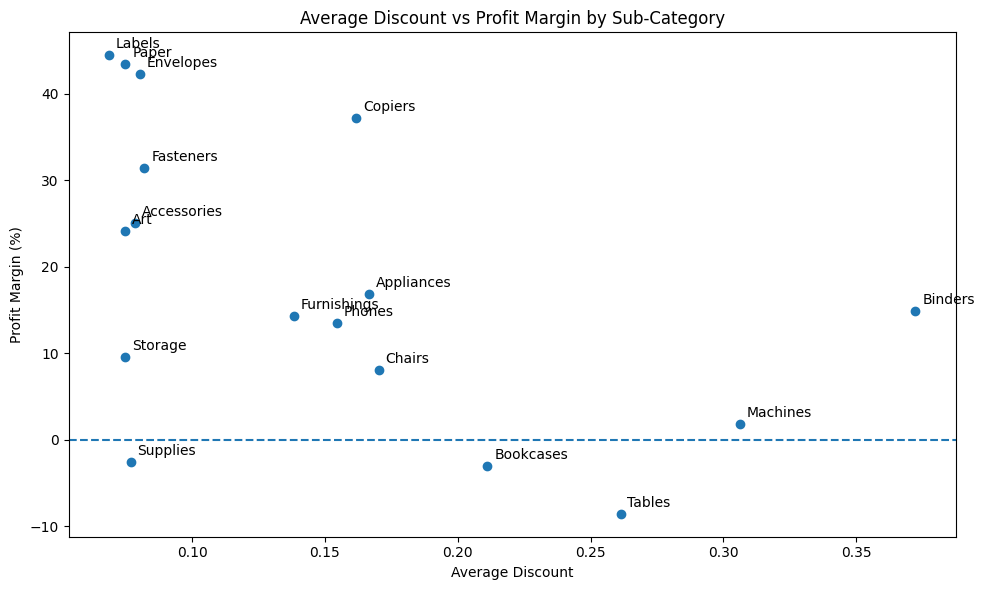

In [52]:


plt.figure(figsize=(10, 6))

plt.scatter(
    discount_profit["Avg_Discount"],
    discount_profit["Profit Margin (%)"]
)

for subcategory, row in discount_profit.iterrows():
    plt.annotate(
        subcategory,
        (row["Avg_Discount"], row["Profit Margin (%)"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Average Discount")
plt.ylabel("Profit Margin (%)")
plt.title("Average Discount vs Profit Margin by Sub-Category")

plt.tight_layout()
plt.show()

The analysis indicates a moderate negative association between average discount and profit margin across sub-categories (r = −0.52). Sub-categories such as Labels, Paper and Envelopes achieve relatively high margins while maintaining low average discounts, whereas Tables, Bookcases and Machines combine relatively high discounts with weak or negative margins. Tables are particularly concerning, recording an average discount of approximately 26% alongside a negative profit margin of 8.6%. However, Binders demonstrate that the relationship is not uniform, as they maintain a positive margin despite having the highest average discount. These findings suggest that discounting should be managed selectively at the sub-category level rather than through a uniform discount strategy.

In [57]:
total_loss = abs(
    df.loc[df["Profit"] < 0, "Profit"].sum()
)

top_10_loss = abs(
    loss_products.head(10)["Profit"].sum()
)

print("Total loss:", total_loss)
print("Top 10 product losses:", top_10_loss)
print(
    "Percentage of total loss:",
    (top_10_loss / total_loss) * 100
)

Total loss: 156131.2857
Top 10 product losses: 29458.3708
Percentage of total loss: 18.86769244736963


This means that approximately 18.9% of all losses in the dataset are concentrated in just 10 products.

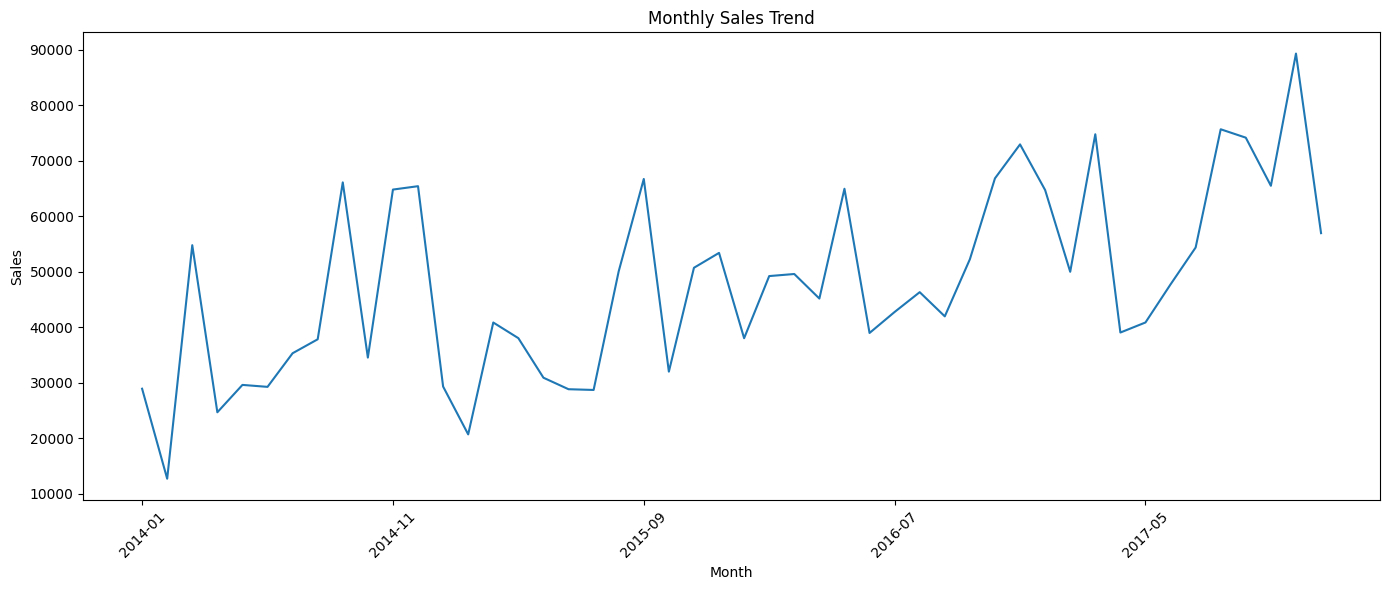

In [59]:
# Sales trend

plt.figure(figsize=(14, 6))

monthly_sales_profit["Sales"].plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

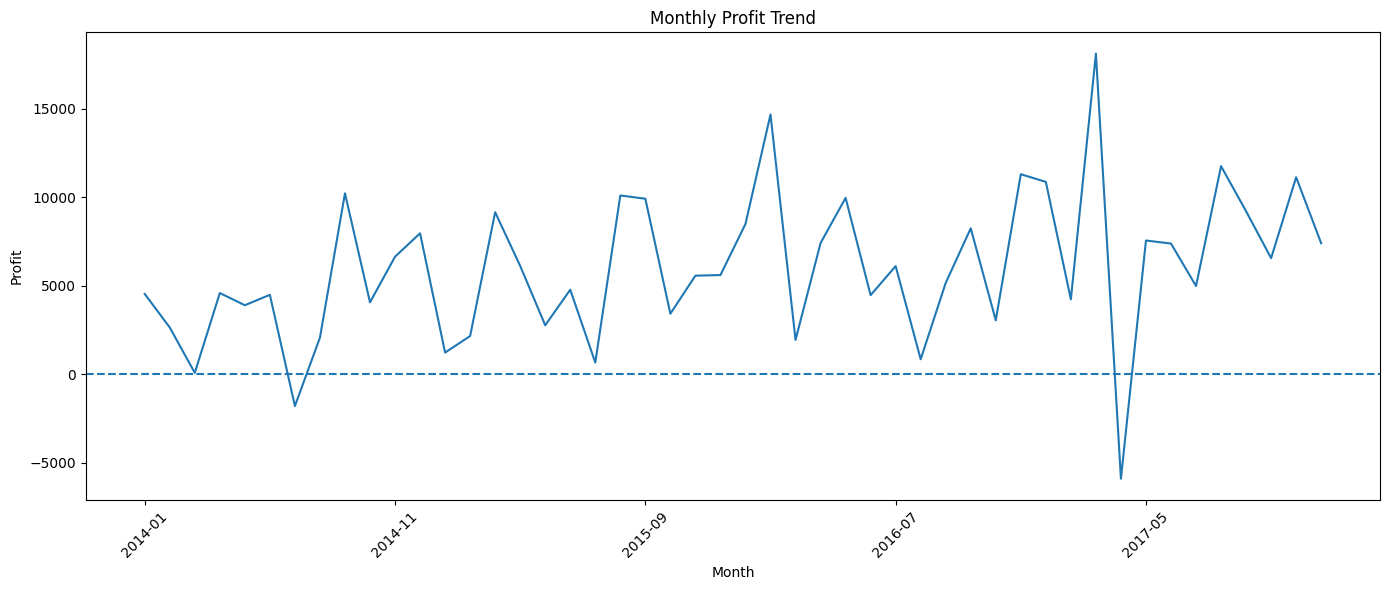

In [60]:
# Profit trend
plt.figure(figsize=(14, 6))

monthly_sales_profit["Profit"].plot()

plt.axhline(0, linestyle="--")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

####  Regional Sales Analysis

In [61]:
# @title
regional_analysis = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Transactions=("Order ID", "count")
    )
)

regional_analysis["Profit Margin (%)"] = (
    regional_analysis["Profit"]
    / regional_analysis["Sales"]
    * 100
)

display(
    regional_analysis.sort_values(
        "Sales",
        ascending=False
    )
)

,Sales,Profit,Orders,Transactions,Profit Margin (%)
Region,,,,,
West,725457.8245,108418.4489,1611,3203,14.944831
East,678781.2400,91522.7800,1401,2848,13.483399
Central,501239.8908,39706.3625,1175,2323,7.921629
South,391721.9050,46749.4303,822,1620,11.934342


West has more sales and a greater profit margin compared to Central.

In [62]:
# @title
state_analysis = (
    df.groupby("State")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
)

state_analysis["Profit Margin (%)"] = (
    state_analysis["Profit"]
    / state_analysis["Sales"]
    * 100
)

display(
    state_analysis.sort_values(
        "Profit",
        ascending=False
    ).head(15)
)

,Sales,Profit,Orders,Profit Margin (%)
State,,,,
California,457687.6315,76381.3871,1021,16.688541
New York,310876.2710,74038.5486,562,23.816082
Washington,138641.2700,33402.6517,256,24.092863
Michigan,76269.6140,24463.1876,117,32.074618
Virginia,70636.7200,18597.9504,115,26.329012
Indiana,53555.3600,18382.9363,73,34.325110
Georgia,49095.8400,16250.0433,91,33.098615
Kentucky,36591.7500,11199.6966,61,30.607163
Minnesota,29863.1500,10823.1874,44,36.242618


In [63]:
#Worst performing states
display(
    state_analysis.sort_values(
        "Profit"
    ).head(15)
)

,Sales,Profit,Orders,Profit Margin (%)
State,,,,
Texas,170188.0458,-25729.3563,487,-15.118192
Ohio,78258.1360,-16971.3766,236,-21.686405
Pennsylvania,116511.9140,-15559.9603,288,-13.354823
Illinois,80166.1010,-12607.8870,276,-15.727205
North Carolina,55603.1640,-7490.9122,136,-13.472097
Colorado,32108.1180,-6527.8579,79,-20.330864
Tennessee,30661.8730,-5341.6936,91,-17.421289
Arizona,35282.0010,-3427.9246,108,-9.715789
Florida,89473.7080,-3399.3017,200,-3.799219


####Segment Analysis

In [64]:
# @title
segment_analysis = (
    df.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
)

segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Profit"]
    / segment_analysis["Sales"]
    * 100
)

display(segment_analysis)

,Sales,Profit,Orders,Customers,Profit Margin (%)
Segment,,,,,
Consumer,1.161401e+06,134119.2092,2586,409,11.548050
Corporate,7.061464e+05,91979.1340,1514,236,13.025506
Home Office,4.296531e+05,60298.6785,909,148,14.034269


Direct Consumers have more sales, more profit but a lower profit margin which could require further investigation to determine whether this is based on discounts.

In [66]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

overall_profit_margin = (
    total_profit / total_sales * 100
)

return_rate = (
    (df["Returned"] == "Yes").mean() * 100
)

print("========== BUSINESS KPI SUMMARY ==========")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
print(f"Return Rate: {return_rate:.2f}%")

========== BUSINESS KPI SUMMARY ==========
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Overall Profit Margin: 12.47%
Return Rate: 8.00%


## Final Findings
## Key Findings

### 1. Revenue concentration
Technology generated the largest share of sales, accounting for approximately 36.4% of total revenue.

### 2. Profitability is not proportional to sales
Several high-revenue sub-categories generated weak or negative profitability. Tables generated approximately 207K in sales but recorded a negative profit of approximately 17.7K.

### 3. Discounting is strongly associated with poor profitability
Higher discount levels were associated with substantially higher loss rates. Discounts of 50% or more resulted in a 100% loss rate in this dataset.

### 4. Product-level losses are concentrated
The top 10 loss-making products accounted for approximately 18.9% of total product-level losses.

### 5. Returns
The dataset had an 8.0% row-level return rate and a 5.91% order-level return rate.

### 6. Data quality
The dataset contains inconsistencies in shipping dates and product identifiers. These issues were investigated and documented rather than silently removed.

## Business Recommendations

### 1. Review high-discount pricing
Management should review discount policies, particularly discounts of 30% and above, because these levels are strongly associated with loss-making transactions.

### 2. Review Tables and Bookcases
Tables and Bookcases should receive priority profitability reviews because they generate substantial revenue while producing negative overall profit.

### 3. Investigate high-loss products
Management should investigate the pricing, procurement costs, and discount structures of the products contributing the largest losses.

### 4. Avoid focusing solely on revenue
High sales volume should not be treated as the sole measure of product performance. Profitability and margin should be incorporated into product decisions.

### 5. Improve data governance
Product IDs, product names and shipping dates should be validated at the point of data entry to improve the reliability of operational reporting.